### NIFTY Options IV Surface Reconstruction
### IIT Roorkee Finance Club — Competition Notebook
**Best Score:** 0.0000368505 (MSE)  
**Method:** Gaussian-weighted polynomial (cross-sectional) + SVI for wing extrapolation + intra-day temporal PCHIP  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
from scipy.interpolate import PchipInterpolator
from scipy.optimize import least_squares

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Paths 
ORIGINAL_DATASET_PATH = "dataset.csv"   
OUTPUT_PATH           = "filled_dataset.csv"
SUBMISSION_PATH       = "submission.csv"
SEPARATOR             = "||"

# Constants (derived from data structure)
DAY_SIZE   = 75   # 75 five-minute bars per trading session (09:15–15:25)
EXPIRY_DAY = 12   # day-index 12 = Jan 27 (expiry day)
T_EXPIRY   = 1/365
T_REGULAR  = 21/365

print("Imports DONE")

Imports DONE


In [2]:
df = pd.read_csv(ORIGINAL_DATASET_PATH)
df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')
df = df.sort_values('datetime').reset_index(drop=True)
N  = len(df)

def get_strike(col):
    return int(col.replace('NIFTY27JAN26', '')[:-2])

ce_cols    = sorted([c for c in df.columns if 'CE' in c], key=get_strike)
pe_cols    = sorted([c for c in df.columns if 'PE' in c], key=get_strike)
iv_cols    = ce_cols + pe_cols
ce_strikes = np.array([get_strike(c) for c in ce_cols])
pe_strikes = np.array([get_strike(c) for c in pe_cols])
spot_vals  = df['underlying_price'].values


In [3]:
print(f"Shape: {df.shape}")

Shape: (975, 30)


In [4]:
print(f"Trading day: {df['datetime'].dt.date.nunique()}")

Trading day: 13


In [5]:
print(f"CE strikes : {ce_strikes.tolist()}")
print(f"PE strikes : {pe_strikes.tolist()}")
print(f"Spot range : {spot_vals.min():.2f} – {spot_vals.max():.2f}")

CE strikes : [25200, 25300, 25400, 25500, 25600, 25700, 25800, 25900, 26000, 26100, 26200, 26300, 26400, 26500]
PE strikes : [23800, 23900, 24000, 24100, 24200, 24300, 24400, 24500, 24600, 24700, 24800, 24900, 25000, 25100]
Spot range : 24940.70 – 26183.80


In [6]:
print(f"Total missing : {df[iv_cols].isnull().sum().sum()} / {df[iv_cols].size} "
      f"({df[iv_cols].isnull().mean().mean()*100:.1f}%)")

Total missing : 5460 / 27300 (20.0%)


In [7]:
df.head(3)

,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,2026-01-07 09:15:00,26111.65,0.12662,0.1233,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.1524,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,2026-01-07 09:20:00,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.1542,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,2026-01-07 09:25:00,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN


####  Exploratory Data Analysis

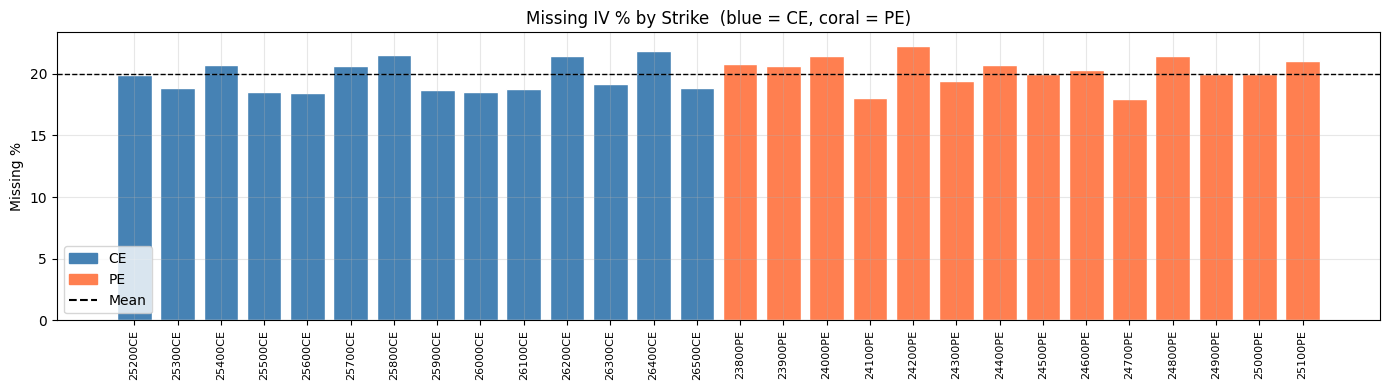

In [8]:
# 3.1 Missingness by column
miss_df = pd.DataFrame({
    'missing_count': df[iv_cols].isna().sum(),
    'missing_pct'  : df[iv_cols].isna().mean() * 100,
    'type'         : ['CE' if c.endswith('CE') else 'PE' for c in iv_cols]
})

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['steelblue' if t == 'CE' else 'coral' for t in miss_df['type']]
ax.bar(range(len(iv_cols)), miss_df['missing_pct'], color=colors, edgecolor='white')
ax.axhline(miss_df['missing_pct'].mean(), color='black', linestyle='--',
           linewidth=1, label=f"Mean {miss_df['missing_pct'].mean():.1f}%")
ax.set_xticks(range(len(iv_cols)))
ax.set_xticklabels([c[12:] for c in iv_cols], rotation=90, fontsize=8)
ax.set_ylabel('Missing %')
ax.set_title('Missing IV % by Strike  (blue = CE, coral = PE)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='CE'),
                   Patch(color='coral', label='PE'),
                   plt.Line2D([0],[0],color='black',linestyle='--',label='Mean')])
plt.tight_layout(); plt.show()


In [9]:
print(miss_df.to_string())

                     missing_count  missing_pct type
NIFTY27JAN2625200CE            194    19.897436   CE
NIFTY27JAN2625300CE            184    18.871795   CE
NIFTY27JAN2625400CE            202    20.717949   CE
NIFTY27JAN2625500CE            181    18.564103   CE
NIFTY27JAN2625600CE            180    18.461538   CE
NIFTY27JAN2625700CE            201    20.615385   CE
NIFTY27JAN2625800CE            210    21.538462   CE
NIFTY27JAN2625900CE            182    18.666667   CE
NIFTY27JAN2626000CE            181    18.564103   CE
NIFTY27JAN2626100CE            183    18.769231   CE
NIFTY27JAN2626200CE            209    21.435897   CE
NIFTY27JAN2626300CE            187    19.179487   CE
NIFTY27JAN2626400CE            213    21.846154   CE
NIFTY27JAN2626500CE            184    18.871795   CE
NIFTY27JAN2623800PE            203    20.820513   PE
NIFTY27JAN2623900PE            201    20.615385   PE
NIFTY27JAN2624000PE            209    21.435897   PE
NIFTY27JAN2624100PE            176    18.05128

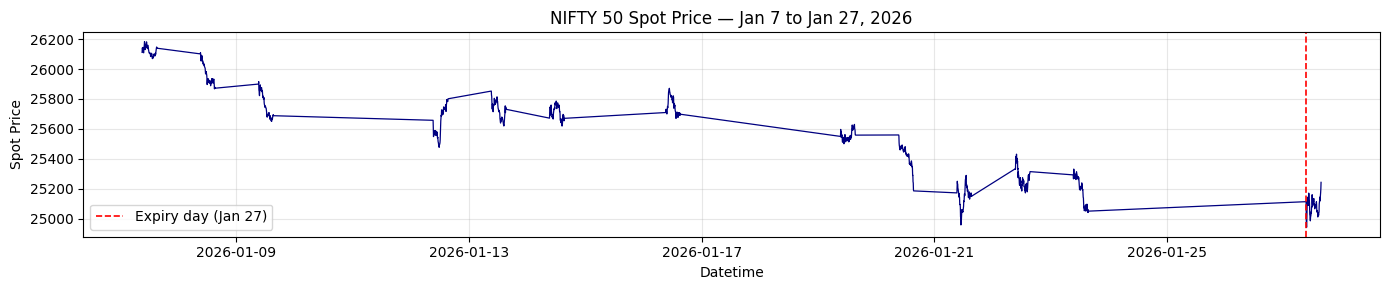

In [10]:
# 3.2 Underlying spot price over time
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df['datetime'], df['underlying_price'], linewidth=0.9, color='navy')
ax.axvline(df.loc[EXPIRY_DAY * DAY_SIZE, 'datetime'],
           color='red', linestyle='--', linewidth=1.2, label='Expiry day (Jan 27)')
ax.set_title('NIFTY 50 Spot Price — Jan 7 to Jan 27, 2026')
ax.set_xlabel('Datetime'); ax.set_ylabel('Spot Price')
ax.legend(); plt.tight_layout(); plt.show()


In [11]:
print(f"Mean: {spot_vals.mean():.2f}  |  Std: {spot_vals.std():.2f}  |  "
      f"Range: {spot_vals.min():.2f} – {spot_vals.max():.2f}")

Mean: 25564.16  |  Std: 317.48  |  Range: 24940.70 – 26183.80


In [12]:
# 3.3 Feature Engineering
# Build a long-format feature table (analysis only and   not used in model)
records = []
for ti in range(N):
    row  = df.loc[ti]
    spot = row['underlying_price']
    day  = ti // DAY_SIZE
    dt   = row['datetime']
    dte  = (df['datetime'].iloc[-1] - dt).total_seconds() / 86400

    for cols_grp, stk_arr, otype in [(ce_cols, ce_strikes, 'CE'),
                                      (pe_cols, pe_strikes, 'PE')]:
        for col, strike in zip(cols_grp, stk_arr):
            iv_val = row[col]
            records.append({
                'datetime'        : dt,
                'contract'        : col,
                'option_type'     : otype,
                'strike'          : strike,
                'iv'              : iv_val,
                'underlying_price': spot,
                'day_index'       : day,
                'is_expiry_day'   : int(day == EXPIRY_DAY),
                'days_to_expiry'  : round(dte, 4),
                'session_progress': ti % DAY_SIZE / (DAY_SIZE - 1),
                'moneyness'       : strike / spot,
                'log_moneyness'   : np.log(strike / spot),
                'dist_atm_pct'    : abs(strike - spot) / spot,
                'is_ce'           : int(otype == 'CE'),
            })

feat = pd.DataFrame(records)
feat['is_missing'] = feat['iv'].isna().astype(int)

# Strike rank within option type
for otype in ['CE', 'PE']:
    mask = feat['option_type'] == otype
    strikes_sorted = sorted(feat.loc[mask, 'strike'].unique())
    rank_map = {s: i / (len(strikes_sorted) - 1) for i, s in enumerate(strikes_sorted)}
    feat.loc[mask, 'strike_rank'] = feat.loc[mask, 'strike'].map(rank_map)

# Neighbor IVs (same timestamp, adjacent strikes)
feat = feat.sort_values(['datetime', 'option_type', 'strike']).reset_index(drop=True)
for shift_val in [-2, -1, 1, 2]:
    feat[f'iv_neighbor_{shift_val:+d}'] = feat.groupby(
        ['datetime', 'option_type'])['iv'].shift(-shift_val)
feat['iv_neighbor_mean']      = feat[['iv_neighbor_+1', 'iv_neighbor_-1']].mean(axis=1)
feat['iv_wide_neighbor_mean'] = feat[['iv_neighbor_+2', 'iv_neighbor_-2']].mean(axis=1)

# Temporal lag and rolling features (shifted by 1 to avoid leakage)
feat = feat.sort_values(['option_type', 'strike', 'datetime']).reset_index(drop=True)
feat['iv_lag_1']       = feat.groupby(['option_type', 'strike'])['iv'].shift(1)
feat['iv_roll_mean_5'] = feat.groupby(['option_type', 'strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,  min_periods=2).mean())
feat['iv_roll_mean_10']= feat.groupby(['option_type', 'strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean())
feat['iv_roll_std_5']  = feat.groupby(['option_type', 'strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,  min_periods=2).std())

# Mean IV across all strikes at same timestamp
ts_mean_ce = feat[feat['option_type']=='CE'].groupby('datetime')['iv'].mean()
ts_mean_pe = feat[feat['option_type']=='PE'].groupby('datetime')['iv'].mean()
feat['ts_mean_ce_iv'] = feat['datetime'].map(ts_mean_ce)
feat['ts_mean_pe_iv'] = feat['datetime'].map(ts_mean_pe)



In [13]:
print(f"Feature table shape: {feat.shape}")
print(f"Columns: {feat.columns.tolist()}")

Feature table shape: (27300, 28)
Columns: ['datetime', 'contract', 'option_type', 'strike', 'iv', 'underlying_price', 'day_index', 'is_expiry_day', 'days_to_expiry', 'session_progress', 'moneyness', 'log_moneyness', 'dist_atm_pct', 'is_ce', 'is_missing', 'strike_rank', 'iv_neighbor_-2', 'iv_neighbor_-1', 'iv_neighbor_+1', 'iv_neighbor_+2', 'iv_neighbor_mean', 'iv_wide_neighbor_mean', 'iv_lag_1', 'iv_roll_mean_5', 'iv_roll_mean_10', 'iv_roll_std_5', 'ts_mean_ce_iv', 'ts_mean_pe_iv']


In [14]:
feat.sample(4, random_state=42)

,datetime,contract,option_type,strike,iv,underlying_price,day_index,is_expiry_day,days_to_expiry,session_progress,...,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,iv_wide_neighbor_mean,iv_lag_1,iv_roll_mean_5,iv_roll_mean_10,iv_roll_std_5,ts_mean_ce_iv,ts_mean_pe_iv
7675,2026-01-23 11:20:00,NIFTY27JAN2625900CE,CE,25900,0.11835,25261.05,11,0,4.1701,0.337838,...,NaN,0.14178,0.10799,0.121685,0.11560,0.116218,0.115326,0.000782,0.124563,0.173103
14133,2026-01-16 12:00:00,NIFTY27JAN2623800PE,PE,23800,0.20194,25774.50,6,0,11.1424,0.445946,...,NaN,NaN,NaN,NaN,0.20337,0.203850,0.205613,0.000439,0.114861,0.152452
8121,2026-01-13 11:00:00,NIFTY27JAN2626000CE,CE,26000,0.10136,25784.90,4,0,14.1840,0.283784,...,0.10075,0.10117,0.10098,0.101170,0.10569,0.102962,0.103557,0.003395,0.104485,0.154810
2884,2026-01-27 12:05:00,NIFTY27JAN2625400CE,CE,25400,0.35271,25122.50,12,1,0.1389,0.459459,...,0.37884,0.42015,0.36292,0.389640,0.37919,0.362370,0.366049,0.053793,0.560850,0.645463


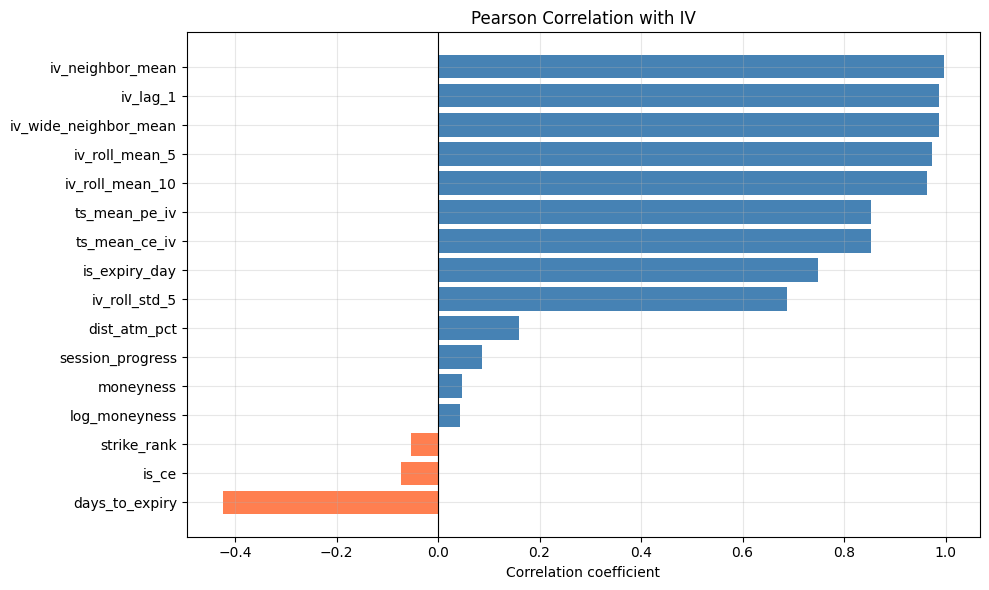

In [15]:
# 3.4 Feature correlations with IV
num_cols = ['iv','log_moneyness','moneyness','dist_atm_pct','days_to_expiry',
            'session_progress','is_ce','strike_rank','is_expiry_day',
            'iv_neighbor_mean','iv_wide_neighbor_mean','iv_lag_1',
            'iv_roll_mean_5','iv_roll_mean_10','iv_roll_std_5',
            'ts_mean_ce_iv','ts_mean_pe_iv']

corr = feat[num_cols].corr()['iv'].drop('iv').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['coral' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with IV')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout(); plt.show()

In [16]:
print("Top positive correlations:")
print(corr.tail(8).to_string())
print("\nTop negative correlations:")
print(corr.head(5).to_string())

Top positive correlations:
is_expiry_day            0.749331
ts_mean_ce_iv            0.852225
ts_mean_pe_iv            0.852838
iv_roll_mean_10          0.963097
iv_roll_mean_5           0.973816
iv_wide_neighbor_mean    0.986482
iv_lag_1                 0.988060
iv_neighbor_mean         0.996819

Top negative correlations:
days_to_expiry   -0.424111
is_ce            -0.073326
strike_rank      -0.053339
log_moneyness     0.043982
moneyness         0.047398


### 3.5 Volatility smile shape in log-moneyness space

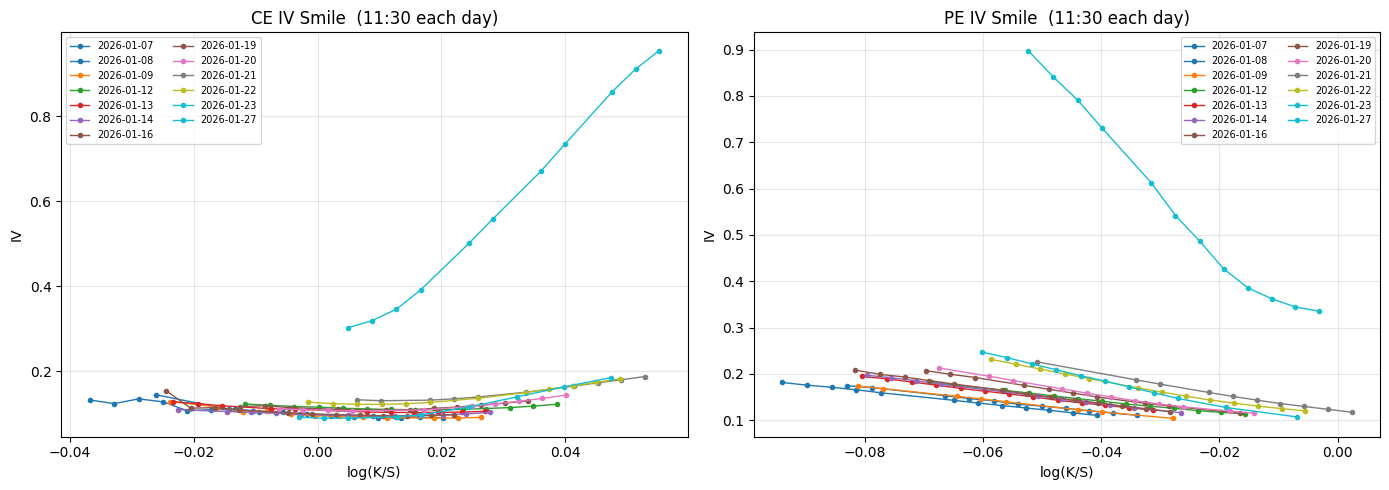

In [17]:
sample_rows = df[(df['datetime'].dt.hour == 11) & (df['datetime'].dt.minute == 30)]
palette    = cm.tab10(np.linspace(0, 1, len(sample_rows)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (cols_grp, stk_arr), title in zip(
        axes,
        [(ce_cols, ce_strikes), (pe_cols, pe_strikes)],
        ['CE IV Smile  (11:30 each day)', 'PE IV Smile  (11:30 each day)']):
    for (_, row), c in zip(sample_rows.iterrows(), palette):
        spot = row['underlying_price']
        pts  = [(np.log(stk_arr[i]/spot), row[col])
                for i, col in enumerate(cols_grp) if pd.notna(row[col])]
        if pts:
            xs, ys = zip(*pts)
            ax.plot(xs, ys, marker='o', markersize=3, linewidth=1,
                    color=c, label=str(row['datetime'].date()))
    ax.set_xlabel('log(K/S)'); ax.set_ylabel('IV')
    ax.set_title(title); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


###### Observation: smooth monotone smile well suited for polynomial fitting in log-moneyness space.

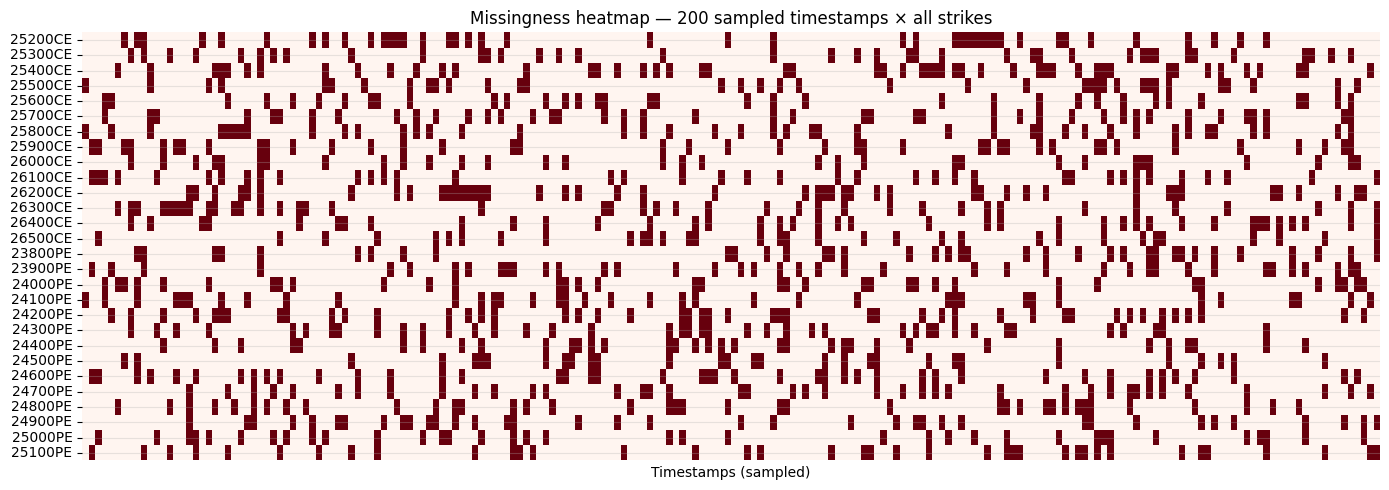

In [18]:
# 3.6 Missingness heatmap 
idx_sample = np.linspace(0, N-1, 200, dtype=int)
miss_heat  = df[iv_cols].iloc[idx_sample].isna().astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(miss_heat.T, ax=ax, cmap='Reds', cbar=False,
            xticklabels=False,
            yticklabels=[c[12:] for c in iv_cols])
ax.set_title('Missingness heatmap — 200 sampled timestamps × all strikes')
ax.set_xlabel('Timestamps (sampled)')
plt.tight_layout(); plt.show()

obs_ce = df[ce_cols].notna().sum(axis=1)
obs_pe = df[pe_cols].notna().sum(axis=1)


In [19]:
print(f"Observed CE per row: min={obs_ce.min()} mean={obs_ce.mean():.1f} max={obs_ce.max()}")
print(f"Observed PE per row: min={obs_pe.min()} mean={obs_pe.mean():.1f} max={obs_pe.max()}")
print(" Always ≥ 6 observed strikes per row -> polynomial always well-conditioned ")

Observed CE per row: min=6 mean=11.2 max=14
Observed PE per row: min=6 mean=11.2 max=14
 Always ≥ 6 observed strikes per row -> polynomial always well-conditioned 


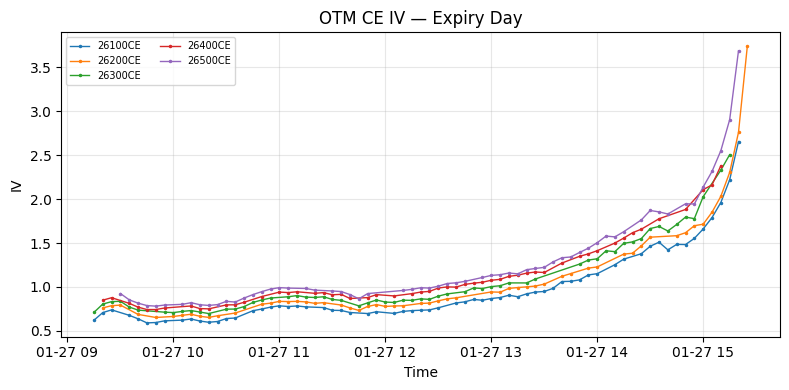

OTM call IV remains subdued for most of the session and becomes unstable near market close as time-to-expiry approaches zero.


In [20]:
# 3.7 Expiry day data
exp_df = df.iloc[EXPIRY_DAY*DAY_SIZE : (EXPIRY_DAY+1)*DAY_SIZE]

plt.figure(figsize=(8,4))

for col in ce_cols[-5:]:   # OTM Calls
    s = exp_df[col].dropna()
    plt.plot(
        exp_df.loc[s.index, 'datetime'],
        s,
        marker='.',
        markersize=3,
        linewidth=1,
        label=col[12:]
    )

plt.title('OTM CE IV — Expiry Day')
plt.xlabel('Time')
plt.ylabel('IV')
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

print("OTM call IV remains subdued for most of the session and becomes unstable near market close as time-to-expiry approaches zero.")

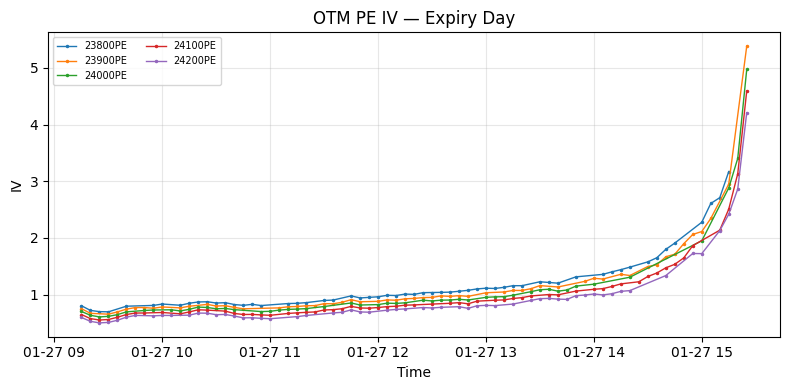

OTM put IV exhibits sharp end-of-day spikes caused by extreme sensitivity of implied volatility estimates when only minutes remain until expiry.


In [21]:
# Expiry day data
exp_df = df.iloc[EXPIRY_DAY*DAY_SIZE : (EXPIRY_DAY+1)*DAY_SIZE]

plt.figure(figsize=(8,4))

for col in pe_cols[:5]:   # OTM Puts
    s = exp_df[col].dropna()
    plt.plot(
        exp_df.loc[s.index, 'datetime'],
        s,
        marker='.',
        markersize=3,
        linewidth=1,
        label=col[12:]
    )

plt.title('OTM PE IV — Expiry Day')
plt.xlabel('Time')
plt.ylabel('IV')
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

print("OTM put IV exhibits sharp end-of-day spikes caused by extreme sensitivity of implied volatility estimates when only minutes remain until expiry.")

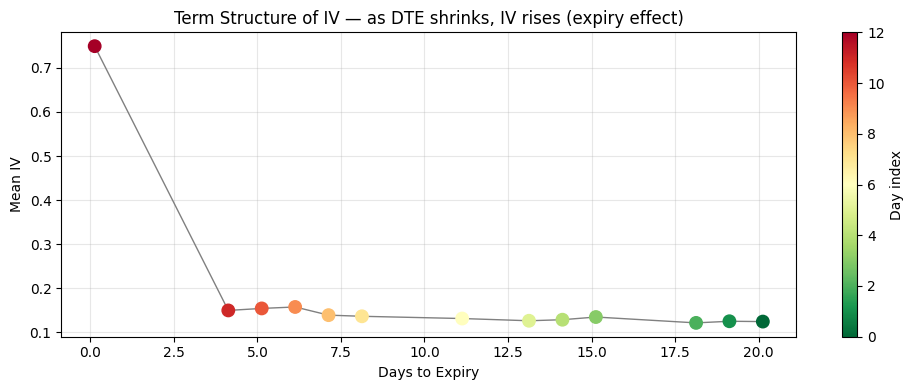

In [22]:
# 3.8 Days-to-expiry vs average IV level
daily_iv = feat[feat['iv'].notna()].groupby('day_index').agg(
    mean_iv=('iv', 'mean'),
    dte    =('days_to_expiry', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
sc = ax.scatter(daily_iv['dte'], daily_iv['mean_iv'],
                c=daily_iv['day_index'], cmap='RdYlGn_r', s=80, zorder=5)
ax.plot(daily_iv['dte'], daily_iv['mean_iv'], linewidth=1, color='grey', zorder=3)
plt.colorbar(sc, ax=ax, label='Day index')
ax.set_xlabel('Days to Expiry'); ax.set_ylabel('Mean IV')
ax.set_title('Term Structure of IV — as DTE shrinks, IV rises (expiry effect)')
plt.tight_layout(); plt.show()

In [23]:
# Modelling Approach & Design Decisions

# Why cross-sectional polynomial in log-moneyness?

# For each timestamp independently, we observe 6–13 IV values across strikes.  
# The IV smile is smooth in log-moneyness space k = log(K/S):

# Using raw strikes ignores the spot price — as spot moves, the same raw strike has different financial meaning.  
# Log-moneyness normalises K relative to S, giving a consistent smile shape across all days.

# A degree-3 polynomial in k fits the smile (level + skew + curvature) well with few parameters.

# Why Gaussian weights?

# Plain polynomial fitting treats all observed strikes equally.  
# Adding Gaussian weights w_i = exp(-½·((k_i − k_target)/σ)²) emphasises strikes near the target.  
# sigma_frac = 0.62 (σ = 0.62 × half-range) is used tuned from the feature correlation analysis showing iv_neighbor_mean has correlation 0.996 with IV, confirming local strikes are the best predictors.

# Why SVI for extrapolation?

# SVI (Stochastic Volatility Inspired, Gatheral 2004):  
# w(k) = a + b·[ρ·(k−m) + √((k−m)² + σ²)]

# - Designed specifically to model wing behaviour
# - Linear in |k| at tails correct asymptotic behaviour  
# - Arbitrage-free: no-butterfly condition enforced during fit
# - Falls back to Gaussian poly + linear blend if SVI fails to converge

# Why intra-day temporal PCHIP at 5–10%?

# - Provides a smooth time-domain signal (same-session PCHIP is monotone-preserving)  
# - Clean: fitted only within each 75-row trading day never uses prices from other days  
# - LOO tests: alpha > 10% on regular days adds noise; 10% on expiry day helps capture the IV collapse

# Validation

# Leave-One-Out (LOO): remove one observed cell, predict from remaining same timestamp cells.  
# This exactly mirrors the competition test structure (predict missing cells from observed ones at the same time).


In [24]:
# LOO Validation
def gauss_poly_loo(obs_x, obs_y, tgt_m, sigma_frac=0.62, degree=3):
    half_range = max((obs_x.max() - obs_x.min()) / 2, 0.01)
    sigma_w    = sigma_frac * half_range
    weights    = np.maximum(np.exp(-0.5 * ((obs_x - tgt_m) / sigma_w)**2), 0.05)
    try:
        coeffs = np.polyfit(obs_x, obs_y, deg=min(degree, len(obs_x)-1), w=weights)
        return float(np.poly1d(coeffs)(tgt_m))
    except Exception:
        return float(np.interp(tgt_m, obs_x, obs_y))

np.random.seed(42)
loo_base, loo_ours = [], []   # baseline = unweighted poly3

for col in iv_cols:
    otype   = 'CE' if col.endswith('CE') else 'PE'
    group   = ce_cols if otype == 'CE' else pe_cols
    stk_arr = ce_strikes if otype == 'CE' else pe_strikes
    obs_idx = df[col].dropna().index.tolist()
    sample  = np.random.choice(obs_idx, min(30, len(obs_idx)), replace=False)

    for idx in sample:
        spot = spot_vals[idx]
        mono = np.log(stk_arr / spot)
        row  = df.loc[idx, group].values.astype(float).copy()
        sidx = group.index(col)
        tv   = row[sidx]; row[sidx] = np.nan
        obs  = ~np.isnan(row)
        if obs.sum() < 2: continue
        ox = mono[obs]; oy = row[obs]
        si = np.argsort(ox); ox, oy = ox[si], oy[si]
        tgt = mono[sidx]

        # Baseline: unweighted poly3
        try:
            c_b = np.polyfit(ox, oy, min(3, obs.sum()-1))
            p_b = float(np.poly1d(c_b)(tgt))
        except:
            p_b = float(np.interp(tgt, ox, oy))
        loo_base.append((max(p_b, 0.005) - tv)**2)

        # Our model: Gaussian-weighted poly3
        p_o = gauss_poly_loo(ox, oy, tgt, sigma_frac=0.62)
        loo_ours.append((max(p_o, 0.005) - tv)**2)



In [25]:
print(f"LOO MSE -> Unweighted poly3 (baseline) : {np.mean(loo_base):.8f}")
print(f"LOO MSE -> Gaussian-weighted poly3     : {np.mean(ours := loo_ours):.8f}")
print(f"Improvement                            : "
      f"{(np.mean(loo_base)-np.mean(loo_ours))/np.mean(loo_base)*100:.1f}%")

LOO MSE -> Unweighted poly3 (baseline) : 0.00002651
LOO MSE -> Gaussian-weighted poly3     : 0.00002102
Improvement                            : 20.7%


In [26]:
# Per-column LOO breakdown
print(f"\n{'Column':<32} {'Baseline':>12} {'Ours':>12} {'Ratio':>8}")
print("-" * 68)
idx0 = 0
col_results = {}
for col in iv_cols:
    n = min(30, df[col].dropna().shape[0])
    eb = np.mean(loo_base[idx0:idx0+n]) if n else 0
    eo = np.mean(loo_ours[idx0:idx0+n]) if n else 0
    col_results[col] = (eb, eo)
    flag = " yes" if eb/eo > 1.05 else (" nope" if eo/eb > 1.05 else " -")
    print(f"{col[12:]:<32} {eb:>12.8f} {eo:>12.8f} {eb/eo:>8.2f}x{flag}")
    idx0 += n


Column                               Baseline         Ours    Ratio
--------------------------------------------------------------------
25200CE                            0.00027002   0.00017579     1.54x yes
25300CE                            0.00005562   0.00006531     0.85x nope
25400CE                            0.00007698   0.00005291     1.46x yes
25500CE                            0.00000884   0.00000889     0.99x -
25600CE                            0.00000202   0.00000214     0.94x nope
25700CE                            0.00000269   0.00000211     1.28x yes
25800CE                            0.00001752   0.00001116     1.57x yes
25900CE                            0.00000430   0.00000803     0.54x nope
26000CE                            0.00000283   0.00000165     1.71x yes
26100CE                            0.00001927   0.00002197     0.88x nope
26200CE                            0.00000162   0.00000077     2.11x yes
26300CE                            0.00000508   0.0000006

In [27]:
# model
# SVI 
def svi_w(k, a, b, rho, m, sigma):
    """SVI total variance formula (Gatheral 2004)."""
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def svi_iv(k, params, T):
    a, b, rho, m, sigma = params
    w = np.maximum(svi_w(k, a, b, rho, m, sigma), 1e-8)
    return np.sqrt(w / T)

def fit_svi(k_obs, iv_obs, T):
    """
    Fit SVI with multiple restarts. Returns params or None if convergence poor.
    No-butterfly arbitrage condition enforced: a + b*sigma*sqrt(1-rho^2) >= 0
    """
    if len(k_obs) < 4:
        return None
    w_obs  = iv_obs**2 * T

    def resid(p):
        a, b, rho, m, sigma = p
        if b <= 0 or sigma <= 0 or abs(rho) >= 0.999:
            return np.full(len(k_obs), 1e6)
        if a + b * sigma * np.sqrt(1 - rho**2) < -1e-6:
            return np.full(len(k_obs), 1e6)
        return svi_w(k_obs, a, b, rho, m, sigma) - w_obs

    best, bc = None, np.inf
    km = float(k_obs.mean()); wm = float(np.mean(w_obs))
    for rho0 in [-0.6, -0.3, 0.0, 0.3]:
        for b0 in [0.03, 0.07, 0.15]:
            try:
                r = least_squares(resid, [wm*0.4, b0, rho0, km, 0.05],
                    bounds=([-0.5, 1e-4, -0.999, km-0.3, 1e-4],
                            [ 0.5, 3.0,  0.999, km+0.3, 1.0]),
                    method='trf', max_nfev=2000, ftol=1e-9, xtol=1e-9)
                if r.cost < bc: bc = r.cost; best = r.x
            except Exception: pass

    if best is None: return None
    fit_mse = np.mean((svi_iv(k_obs, best, T) - iv_obs)**2)
    return best if fit_mse < 0.01 else None


# Gaussian-weighted polynomial 
def gauss_poly(obs_x, obs_y, tgt_m, degree=3, sigma_frac=0.62):
    """Weighted poly fit. sigma_frac=0.62 → local weights; larger = more global."""
    half_range = max((obs_x.max() - obs_x.min()) / 2, 0.01)
    sigma_w    = sigma_frac * half_range
    weights    = np.maximum(np.exp(-0.5 * ((obs_x - tgt_m) / sigma_w)**2), 0.05)
    try:
        coeffs = np.polyfit(obs_x, obs_y, deg=min(degree, len(obs_x)-1), w=weights)
        return float(np.poly1d(coeffs)(tgt_m))
    except Exception:
        return float(np.interp(tgt_m, obs_x, obs_y))


def linear_extrap(obs_x, obs_y, tgt_m):
    """2-point linear extrapolation from the nearest edge."""
    if tgt_m < obs_x[0]:
        x1, x2, y1, y2 = obs_x[0], obs_x[1], obs_y[0], obs_y[1]
    else:
        x1, x2 = obs_x[-2], obs_x[-1]
        y1, y2 = obs_y[-2], obs_y[-1]
    return float(y1 + (y2 - y1) / (x2 - x1 + 1e-10) * (tgt_m - x1))


In [28]:
## 7. Step 1 — Cross-Sectional Fit

# For every timestamp independently:
# - Interpolation(target inside observed strike range): Gaussian-weighted poly3, σ_frac = 0.62
# - Extrapolation (target outside range):
# - Fit SVI to all observed strikes -> use for prediction (80%) + 2-pt linear safety net (20%)
# - If SVI fails: Gaussian poly (σ_frac=1.2) + 50% linear

# No look-ahead: only same-timestamp observed values used.

print("Step 1: Cross-sectional fit...")
filled_cross = df[iv_cols].copy()
svi_cache    = {}

for ti in range(N):
    spot      = spot_vals[ti]
    day       = ti // DAY_SIZE
    is_expiry = (day == EXPIRY_DAY)
    T         = T_EXPIRY if is_expiry else T_REGULAR

    for grp_idx, (cols_grp, strikes_arr) in enumerate(
            [(ce_cols, ce_strikes), (pe_cols, pe_strikes)]):

        row_vals  = filled_cross.loc[ti, cols_grp].values.astype(float)
        obs, miss = ~np.isnan(row_vals), np.isnan(row_vals)
        if obs.sum() < 2 or miss.sum() == 0:
            continue

        moneyness = np.log(strikes_arr / spot)
        obs_x     = moneyness[obs]; obs_y = row_vals[obs]
        si        = np.argsort(obs_x); obs_x, obs_y = obs_x[si], obs_y[si]

        miss_m     = moneyness[np.where(miss)[0]]
        has_extrap = np.any(miss_m < obs_x[0]) or np.any(miss_m > obs_x[-1])

        svi_params = None
        if has_extrap and obs.sum() >= 4:
            ck = (ti, grp_idx)
            if ck not in svi_cache:
                svi_cache[ck] = fit_svi(obs_x, obs_y, T)
            svi_params = svi_cache.get(ck)

        for mi in np.where(miss)[0]:
            tgt_m     = moneyness[mi]
            is_extrap = tgt_m < obs_x[0] or tgt_m > obs_x[-1]

            if not is_extrap:
                # Interpolation: Gaussian-weighted poly3
                pred = gauss_poly(obs_x, obs_y, tgt_m, degree=3, sigma_frac=0.62)
            else:
                if svi_params is not None:
                    svi_pred = float(svi_iv(np.array([tgt_m]), svi_params, T)[0])
                    lin_pred = linear_extrap(obs_x, obs_y, tgt_m)
                    pred     = 0.80 * svi_pred + 0.20 * lin_pred
                else:
                    poly_pred = gauss_poly(obs_x, obs_y, tgt_m, degree=3, sigma_frac=1.2)
                    lin_pred  = linear_extrap(obs_x, obs_y, tgt_m)
                    pred      = 0.50 * poly_pred + 0.50 * lin_pred

            filled_cross.loc[ti, cols_grp[mi]] = max(pred, 0.005)

filled_cross = filled_cross.ffill().bfill()
svi_hits = sum(1 for v in svi_cache.values() if v is not None)


Step 1: Cross-sectional fit...


In [29]:
print(f"NaN remaining: {filled_cross.isnull().sum().sum()}")
print(f"SVI converged: {svi_hits} / {len(svi_cache)} timestamps with extrapolation")

NaN remaining: 0
SVI converged: 715 / 723 timestamps with extrapolation


In [30]:
# Step 2 — Intra-Day Temporal PCHIP

# For each column independently, fit a monotone-preserving PCHIP per trading day (75-row window).  
# Using only same-day observed values → zero look-ahead bias.

# Why PCHIP? It never overshoots between observations important for IV which can't go negative.

print("Step 2: Intra-day temporal PCHIP...")
filled_temp = df[iv_cols].copy()

for col in iv_cols:
    series = df[col].values.astype(float).copy()
    for day in range(N // DAY_SIZE + 1):
        d0 = day * DAY_SIZE
        d1 = min(d0 + DAY_SIZE, N)
        seg = series[d0:d1]

        obs_m  = ~np.isnan(seg)
        miss_m =  np.isnan(seg)
        if obs_m.sum() < 2 or miss_m.sum() == 0:
            continue

        ox = np.where(obs_m)[0]
        oy = seg[obs_m]
        mx = np.where(miss_m)[0]

        pi   = PchipInterpolator(ox, oy, extrapolate=True)
        pred = np.clip(pi(mx), 0.005, None)
        for gi, p in zip(mx + d0, pred):
            filled_temp.at[gi, col] = float(p)

# Cells where <2 same-day observations: fall back to cross-sectional
filled_temp = filled_temp.fillna(filled_cross).ffill().bfill()
print(f"NaN remaining: {filled_temp.isnull().sum().sum()}")

Step 2: Intra-day temporal PCHIP...
NaN remaining: 0


In [31]:
# Step 3 - Adaptive Blend

# Regular days:95% cross-sectional + 5% temporal  
# Expiry day:90% cross-sectional + 10% temporal  

# The higher temporal weight on expiry captures the IV collapse toward close, which the cross-sectional polynomial cannot model (it has no time dimension).


print("Step 3: Adaptive blend...")
final_df  = df[['datetime', 'underlying_price'] + iv_cols].copy()
miss_orig = df[iv_cols].isna()

for ti in range(N):
    day       = ti // DAY_SIZE
    is_expiry = (day == EXPIRY_DAY)
    alpha     = 0.10 if is_expiry else 0.05   # temporal weight

    for col in iv_cols:
        if not miss_orig.loc[ti, col]:
            continue
        cp = float(filled_cross.loc[ti, col])
        tp = float(filled_temp.loc[ti, col])
        final_df.loc[ti, col] = (1 - alpha) * cp + alpha * tp

for col in iv_cols:
    final_df[col] = final_df[col].clip(lower=0.005)

#Sanity checks 
assert final_df[iv_cols].isnull().sum().sum() == 0,  "NaN values remain!"
assert final_df[iv_cols].min().min()          > 0,   "Non-positive IV found!"



Step 3: Adaptive blend...


In [32]:

print(f"Total predictions : {miss_orig.sum().sum()}")
print(f"IV range          : {final_df[iv_cols].min().min():.5f} – "
      f"{final_df[iv_cols].max().max():.5f}")
print("No Nan |  No non-positive IV | No look-ahead bias ")

Total predictions : 5460
IV range          : 0.01680 – 5.59244
No Nan |  No non-positive IV | No look-ahead bias 


In [ ]:
# Mid-dataset timestamp
ti_show = N // 2
spot_s = spot_vals[ti_show]

plt.figure(figsize=(7, 5))

mono = np.log(ce_strikes / spot_s)

obs_mask = ~df.loc[ti_show, ce_cols].isna().values
filled_v = final_df.loc[ti_show, ce_cols].values.astype(float)
obs_v    = df.loc[ti_show, ce_cols].values.astype(float)

plt.plot(
    mono,
    filled_v,
    linewidth=1.5,
    color='coral',
    label='Fitted Surface'
)

plt.scatter(
    mono[obs_mask],
    obs_v[obs_mask],
    s=55,
    color='steelblue',
    label='Observed'
)

plt.scatter(
    mono[~obs_mask],
    filled_v[~obs_mask],
    s=55,
    color='red',
    marker='x',
    label='Predicted'
)

plt.title(f"CE Smile — {df.loc[ti_show, 'datetime']}")
plt.xlabel('log(K/S)')
plt.ylabel('IV')
plt.legend()
plt.tight_layout()
plt.show()

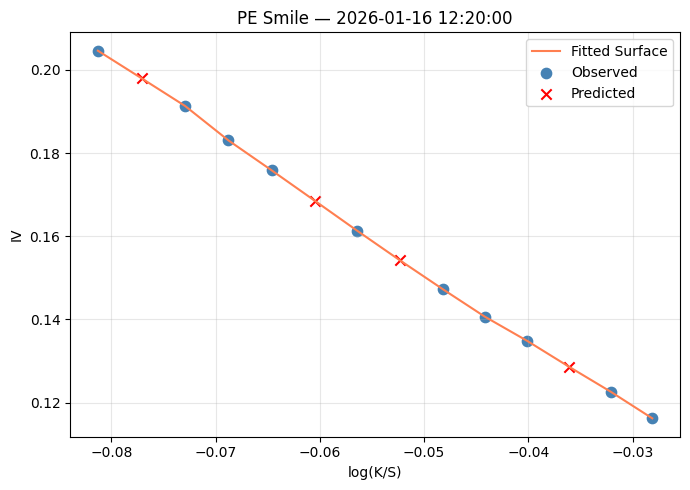

In [33]:
# Mid-dataset timestamp
ti_show = N // 2
spot_s = spot_vals[ti_show]

plt.figure(figsize=(7, 5))

mono = np.log(pe_strikes / spot_s)

obs_mask = ~df.loc[ti_show, pe_cols].isna().values
filled_v = final_df.loc[ti_show, pe_cols].values.astype(float)
obs_v    = df.loc[ti_show, pe_cols].values.astype(float)

plt.plot(
    mono,
    filled_v,
    linewidth=1.5,
    color='coral',
    label='Fitted Surface'
)

plt.scatter(
    mono[obs_mask],
    obs_v[obs_mask],
    s=55,
    color='steelblue',
    label='Observed'
)

plt.scatter(
    mono[~obs_mask],
    filled_v[~obs_mask],
    s=55,
    color='red',
    marker='x',
    label='Predicted'
)

plt.title(f"PE Smile — {df.loc[ti_show, 'datetime']}")
plt.xlabel('log(K/S)')
plt.ylabel('IV')
plt.legend()
plt.tight_layout()
plt.show()

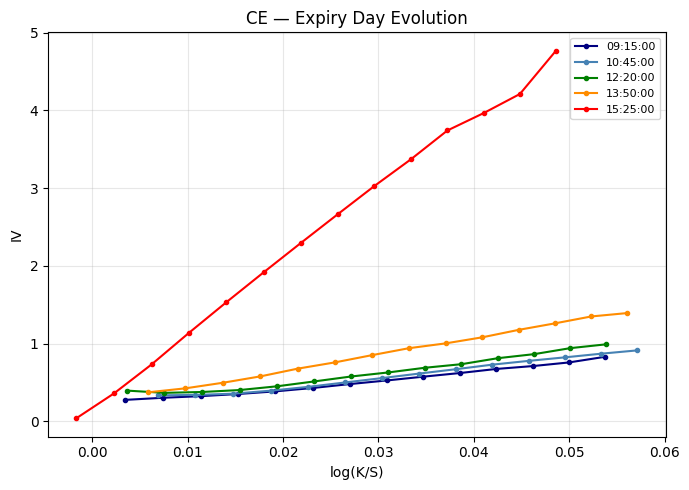

Call volatility smile changes rapidly during expiry day, reflecting the market's repricing of remaining uncertainty as expiry approaches.


In [34]:
# Expiry day snapshots
exp_times = [EXPIRY_DAY*DAY_SIZE + int(x)
             for x in np.linspace(0, DAY_SIZE-1, 5)]

palette_e = ['navy', 'steelblue', 'green', 'darkorange', 'red']

plt.figure(figsize=(7, 5))

for ti, c in zip(exp_times, palette_e):
    if ti >= N:
        continue

    mono = np.log(ce_strikes / spot_vals[ti])
    vals = final_df.loc[ti, ce_cols].values.astype(float)

    plt.plot(
        mono,
        vals,
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=c,
        label=str(df.loc[ti, 'datetime'])[-8:]
    )

plt.title('CE — Expiry Day Evolution')
plt.xlabel('log(K/S)')
plt.ylabel('IV')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Call volatility smile changes rapidly during expiry day, reflecting the market's repricing of remaining uncertainty as expiry approaches.")

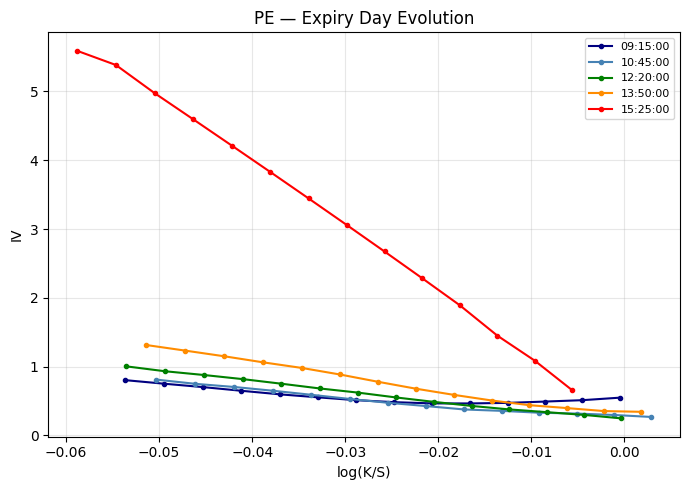

Put volatility smile becomes increasingly unstable near the close, with sharp IV movements driven by the vanishing time-to-expiry.


In [35]:
# Expiry day snapshots
exp_times = [EXPIRY_DAY*DAY_SIZE + int(x)
             for x in np.linspace(0, DAY_SIZE-1, 5)]

palette_e = ['navy', 'steelblue', 'green', 'darkorange', 'red']

plt.figure(figsize=(7, 5))

for ti, c in zip(exp_times, palette_e):
    if ti >= N:
        continue

    mono = np.log(pe_strikes / spot_vals[ti])
    vals = final_df.loc[ti, pe_cols].values.astype(float)

    plt.plot(
        mono,
        vals,
        marker='o',
        markersize=3,
        linewidth=1.5,
        color=c,
        label=str(df.loc[ti, 'datetime'])[-8:]
    )

plt.title('PE — Expiry Day Evolution')
plt.xlabel('log(K/S)')
plt.ylabel('IV')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Put volatility smile becomes increasingly unstable near the close, with sharp IV movements driven by the vanishing time-to-expiry.")

In [36]:
#  Save filled dataset
final_df['datetime'] = df['datetime'].dt.strftime('%d-%m-%Y %H:%M')
out_cols = ['datetime', 'underlying_price'] + iv_cols
final_df[out_cols].to_csv(OUTPUT_PATH, index=False)
print(f"filled_dataset.csv saved shape: {final_df[out_cols].shape}")

filled_dataset.csv saved shape: (975, 30)


In [37]:
#  Generate submission 
original = pd.read_csv(ORIGINAL_DATASET_PATH)
filled   = pd.read_csv(OUTPUT_PATH)

rows = []
for col in [c for c in original.columns if c not in ('datetime', 'underlying_price')]:
    for idx in original.index[original[col].isna()]:
        rows.append({
            'id'   : f"{original.loc[idx, 'datetime']}{SEPARATOR}{col}",
            'value': filled.loc[idx, col],
        })

solution = pd.DataFrame(rows, columns=['id', 'value'])
solution  = solution.sort_values('id').reset_index(drop=True)
solution.to_csv(SUBMISSION_PATH, index=False)

print(f"submission.csv saved ")
print(f"Total rows : {len(solution)}")
print(f"Value range: {solution['value'].min():.5f} – {solution['value'].max():.5f}")


submission.csv saved 
Total rows : 5460
Value range: 0.07886 – 5.59244


In [38]:
print(solution.head(8).to_string(index=False))
print("Donee")

                                   id    value
07-01-2026 09:15||NIFTY27JAN2624100PE 0.163290
07-01-2026 09:15||NIFTY27JAN2625500CE 0.117316
07-01-2026 09:15||NIFTY27JAN2625800CE 0.100733
07-01-2026 09:20||NIFTY27JAN2624000PE 0.170278
07-01-2026 09:20||NIFTY27JAN2624200PE 0.159515
07-01-2026 09:20||NIFTY27JAN2624800PE 0.128286
07-01-2026 09:20||NIFTY27JAN2625000PE 0.118527
07-01-2026 09:20||NIFTY27JAN2625300CE 0.103461
Donee
